##**Credit Risk EDA Project**



**Objective:**  
Perform Exploratory Data Analysis (EDA) for a consumer finance company to understand  
**which client and loan attributes are associated with higher risk of default**  
("clients with payment difficulties") vs "all other cases".

**Datasets used:**
- `application_data.csv` – Client info at time of loan application (includes target variable).
- `previous_application.csv` – Previous loan applications for the same clients.
- `columns_description.csv` – Data dictionary.

**Key Tasks:**
1. Data understanding & cleaning (missing values, types, outliers).
2. Check and understand target imbalance.
3. Univariate, segmented univariate, and bivariate analysis.
4. Correlation analysis for:
   - Clients with payment difficulties.
   - All other cases.
5. Identify key driver variables and provide business recommendations.

---



##IMPORT LIBRARIES & SET DATA PATH

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import panda as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style & display options
plt.style.use("default")
sns.set()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Folder in the Google Drive where the CSVs are stored
#Make sure the three datasets are in the driving in a folder named EDA_Credit_Case_Study
DATA_PATH = "/content/drive/MyDrive/EDA_Credit_Case_Study/"

# Optional: check that the files are actually there
print(os.listdir(DATA PATH))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['application_data.csv', 'columns_description.csv', 'previous_application.csv']


##Load the Three datasets

In [ ]:
application_data_path = DATA_PATH + "application_data.csv"
previous_app_data_path = DATA_PATH + "previous_application.csv"
columns_desc_path = DATA_PATH + "columns_description.csv"

app = pd.read_csv(application_data_path)
prev_app = pd.read_csv(previous_app_data_path)
#col_desc = pd.read_csv(columns_desc_path)
#UnicodeDecodeError, to avoid that, Latin1 loads ANY byte 0–255 → no error
col_desc = pd.read_csv(columns_desc_path, encoding="latin1")

print("Shapes:")
print("application_data:", app.shape)
print("previous_application:", prev_app.shape)
print("columns_description:", col_desc.shape)


Shapes:
application_data: (307511, 122)
previous_application: (1670214, 37)
columns_description: (160, 5)


##Quick data peek

In [ ]:
print("Application data shape:", app.shape)
display(app.head())
display(app.info())

print("\nTarget value counts:")
print(app['TARGET'].value_counts(dropna=False))
print("\nTarget distribution (%):")
print(app['TARGET'].value_counts(normalize=True) * 100)


Application data shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


None


Target value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target distribution (%):
TARGET
0   91.93
1    8.07
Name: proportion, dtype: float64


## Data dictionary peek

In [ ]:
display(col_desc.head())
display(col_desc.info())

# Standardise column names for easier handling later
col_desc.columns = [c.strip().upper() for c in col_desc.columns]
col_desc.columns


,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_data,CODE_GENDER,Gender of the client,NaN
4,7,application_data,FLAG_OWN_CAR,Flag if the client owns a car,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   160 non-null    int64 
 1   Table        160 non-null    object
 2   Row          160 non-null    object
 3   Description  160 non-null    object
 4   Special      69 non-null     object
dtypes: int64(1), object(4)
memory usage: 6.4+ KB


None

Index(['UNNAMED: 0', 'TABLE', 'ROW', 'DESCRIPTION', 'SPECIAL'], dtype='object')

##Helper functions

In [ ]:
# Missing value summary
def missing_value_summary(df, sort=True):
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    mv_percent = (mv / len(df)) * 100
    summary = pd.DataFrame({
        'missing_count': mv,
        'missing_percent': mv_percent
    })
    if sort:
        summary = summary.sort_values(by='missing_percent', ascending=False)
    return summary

# Numeric distribution (with optional TARGET)
def plot_numeric_dist(df, col, target=None, bins=50):
    plt.figure(figsize=(8, 5))
    if target is None:
        sns.histplot(data=df, x=col, bins=bins, kde=True)
        plt.title(f"Distribution of {col}")
    else:
        sns.histplot(
            data=df, x=col, bins=bins, kde=True,
            hue=target, stat="density", common_norm=False
        )
        plt.title(f"Distribution of {col} by {target}")
    plt.tight_layout()
    plt.show()

# Categorical distribution (with optional TARGET)
def plot_categorical_dist(df, col, target=None, rotate_xticks=True):
    plt.figure(figsize=(8, 5))
    if target is None:
        sns.countplot(data=df, x=col)
        plt.title(f"Count plot of {col}")
    else:
        sns.countplot(data=df, x=col, hue=target)
        plt.title(f"{col} by {target}")
    if rotate_xticks:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Top correlations helper
def get_top_correlations(df, n=10, ignore_cols=None):
    if ignore_cols is not None:
        df = df.drop(columns=ignore_cols, errors="ignore")
    corr = df.corr()
    corr_unstacked = corr.abs().unstack()
    corr_unstacked = corr_unstacked[
        corr_unstacked.index.get_level_values(0)
        < corr_unstacked.index.get_level_values(1)
    ]
    top_corrs = corr_unstacked.sort_values(ascending=False).head(n)
    return top_corrs


##Data understanding & stats

- Understand the structure and basic statistics of `application_data`.
- Check data types.
- Identify obvious issues (e.g., weird values, negative days, etc.).


In [ ]:
display(app.describe().T)
app.dtypes.head(30)


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,"307,511.00","278,180.52","102,790.18","100,002.00","189,145.50","278,202.00","367,142.50","456,255.00"
TARGET,"307,511.00",0.08,0.27,0.00,0.00,0.00,0.00,1.00
CNT_CHILDREN,"307,511.00",0.42,0.72,0.00,0.00,0.00,1.00,19.00
AMT_INCOME_TOTAL,"307,511.00","168,797.92","237,123.15","25,650.00","112,500.00","147,150.00","202,500.00","117,000,000.00"
AMT_CREDIT,"307,511.00","599,026.00","402,490.78","45,000.00","270,000.00","513,531.00","808,650.00","4,050,000.00"
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,"265,992.00",0.01,0.11,0.00,0.00,0.00,0.00,9.00
AMT_REQ_CREDIT_BUREAU_WEEK,"265,992.00",0.03,0.20,0.00,0.00,0.00,0.00,8.00
AMT_REQ_CREDIT_BUREAU_MON,"265,992.00",0.27,0.92,0.00,0.00,0.00,0.00,27.00
AMT_REQ_CREDIT_BUREAU_QRT,"265,992.00",0.27,0.79,0.00,0.00,0.00,0.00,261.00


,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
AMT_CREDIT,float64
AMT_ANNUITY,float64


##Basic type conversions

In [ ]:

# Convert binary Y/N columns to 1/0
binary_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

for col in binary_cols:
    if col in app.columns:
        app[col] = app[col].map({'Y': 1, 'N': 0})

# Convert DAYS_BIRTH and DAYS_EMPLOYED to numeric if needed
# (They are usually already numeric and negative — this is fine for now)
# We will create AGE_YEARS and EMPLOYED_YEARS later in feature engineering.

print("Cell 9 completed. Converted binary Y/N columns to 1/0 where applicable.")


Cell 9 completed. Converted binary Y/N columns to 1/0 where applicable.


##Missing value analysis

Steps:
- Identify columns with missing values and their percentage.
- Drop columns with very high missingness.
- Impute remaining missing values (numerical and categorical) with justified methods.


In [ ]:
mv_summary = missing_value_summary(app)
display(mv_summary.head(30))

# Example rule: drop columns with > 40% missing
threshold = 40
cols_to_drop = mv_summary[mv_summary['missing_percent'] > threshold].index.tolist()
print("Number of columns to drop:", len(cols_to_drop))

# Working copy for EDA
app_eda = app.drop(columns=cols_to_drop)
app_eda.shape


,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


Number of columns to drop: 49


(307511, 73)

##Imputation

In [ ]:
num_cols = app_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = app_eda.select_dtypes(include=['object']).columns.tolist()

if 'TARGET' in num_cols:
    num_cols.remove('TARGET')

# Numeric: median
for col in num_cols:
    if app_eda[col].isnull().sum() > 0:
        app_eda[col].fillna(app_eda[col].median(), inplace=True)

# Categorical: mode
for col in cat_cols:
    if app_eda[col].isnull().sum() > 0:
        mode_val = app_eda[col].mode()[0]
        app_eda[col].fillna(mode_val, inplace=True)

missing_value_summary(app_eda)


/tmp/ipython-input-2957687420.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_eda[col].fillna(app_eda[col].median(), inplace=True)
/tmp/ipython-input-2957687420.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,missing_count,missing_percent


##Outlier exploration


==== AMT_INCOME_TOTAL ====


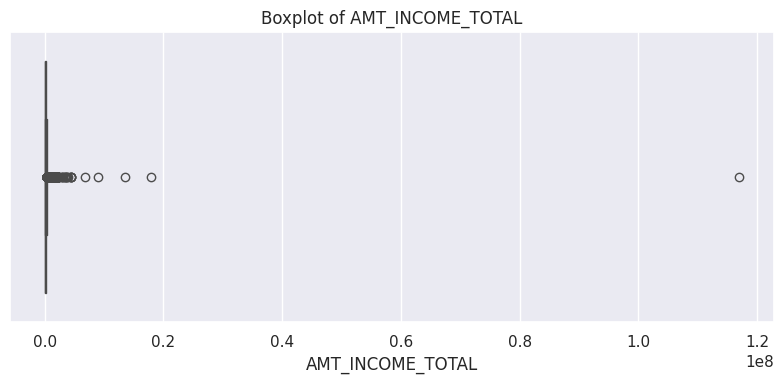

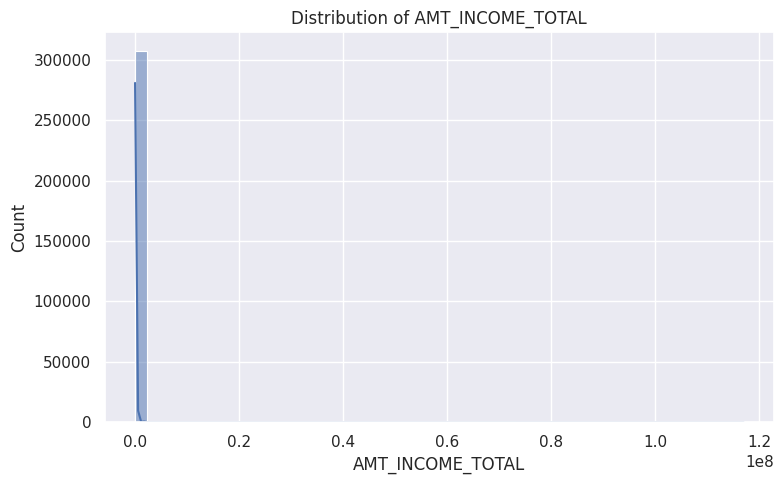


==== AMT_CREDIT ====


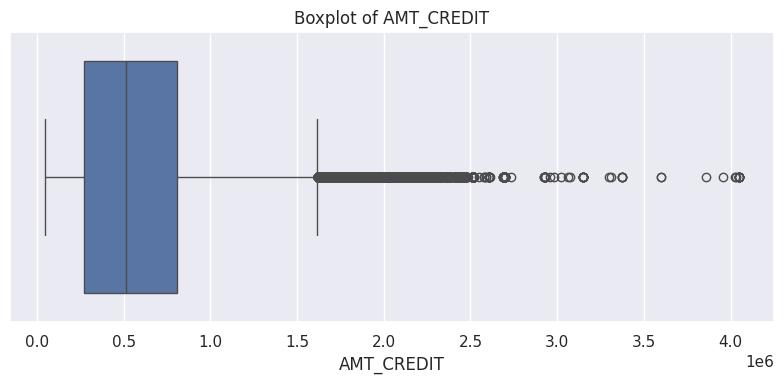

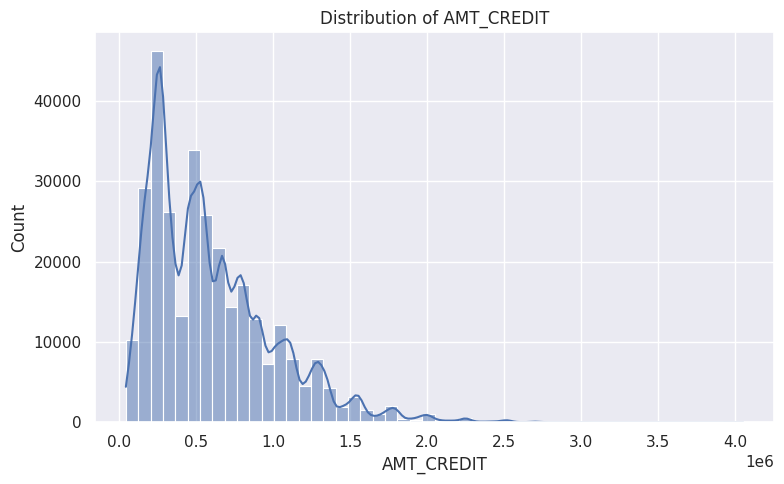


==== AMT_ANNUITY ====


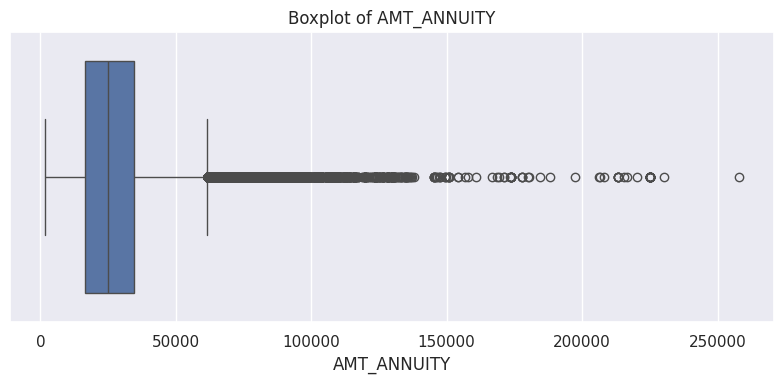

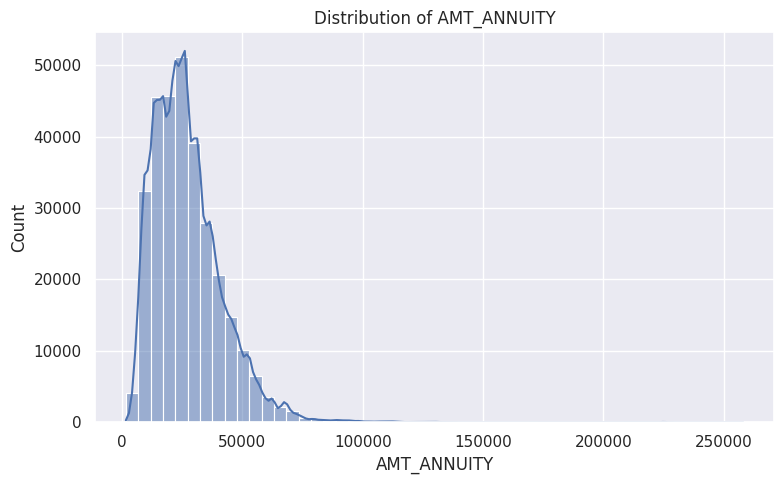


==== AMT_GOODS_PRICE ====


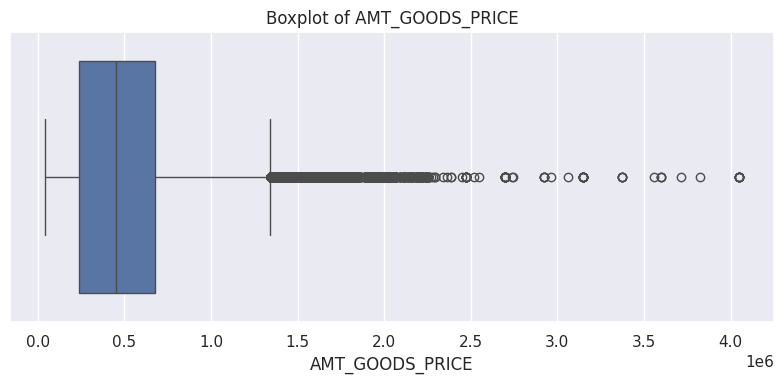

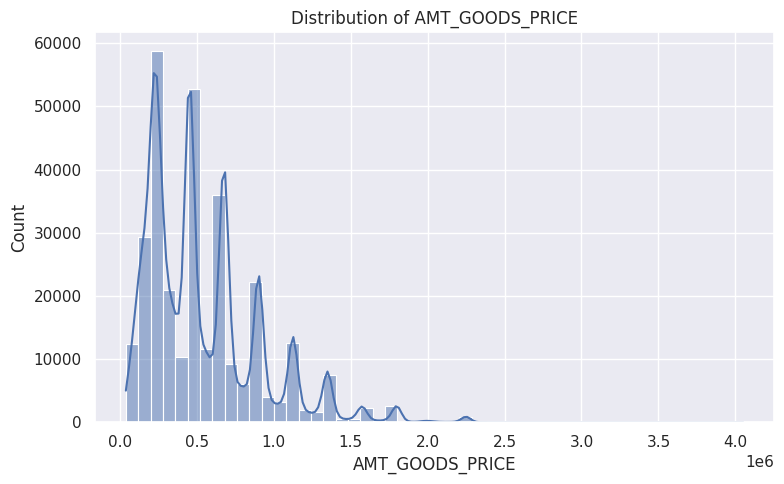


==== DAYS_BIRTH ====


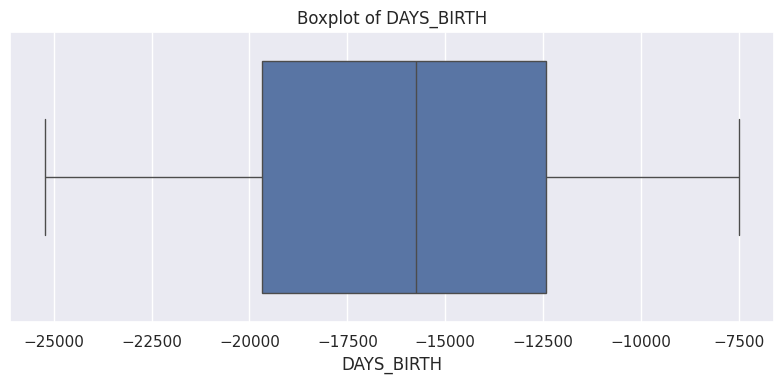

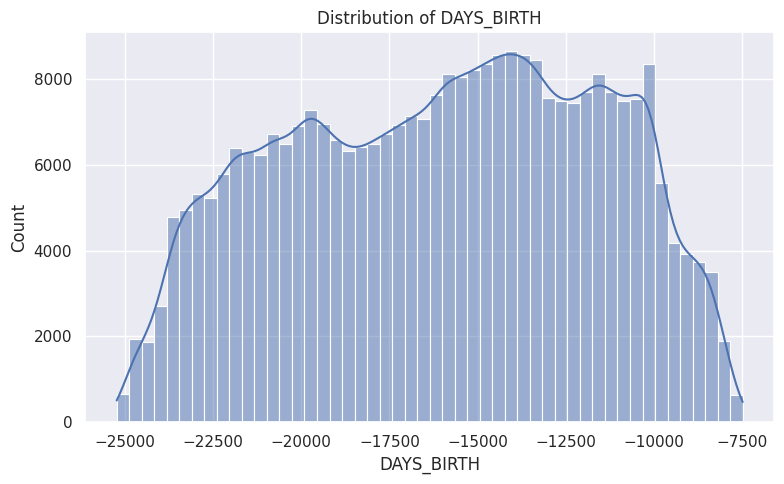


==== DAYS_EMPLOYED ====


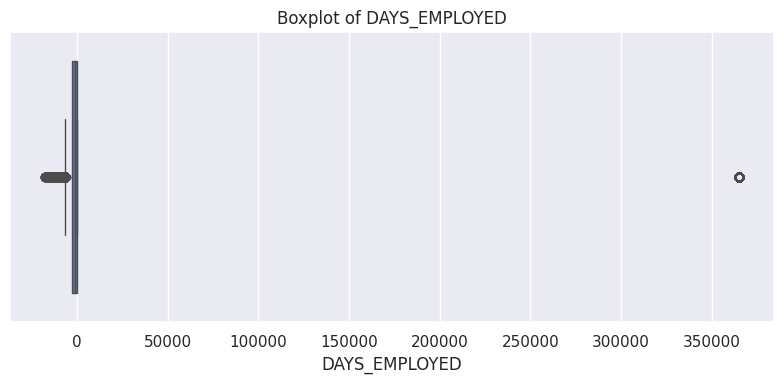

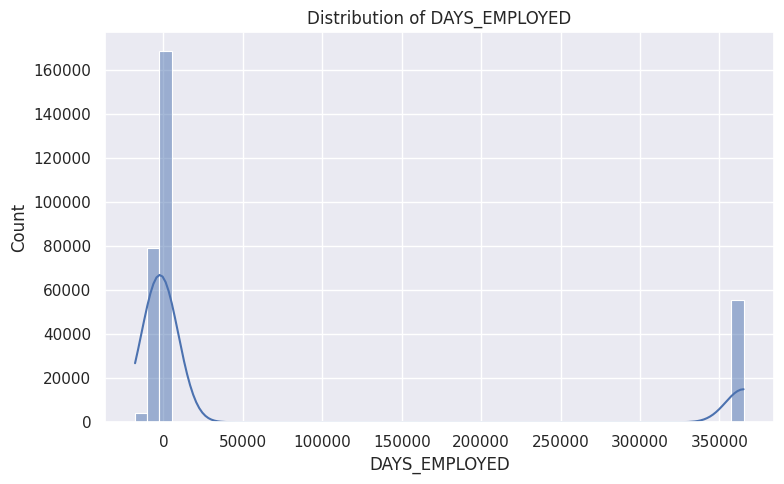

In [ ]:
key_num_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

for col in key_num_cols:
    if col in app_eda.columns:
        print(f"\n==== {col} ====")
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=app_eda[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.show()

        plot_numeric_dist(app_eda, col)


### Outlier Analysis Summary

1. **AMT_INCOME_TOTAL** shows extreme outliers (up to 120M+). These represent a very small minority of clients and are kept as-is for EDA.
2. **AMT_CREDIT** and **AMT_GOODS_PRICE** are highly right-skewed with many large-value outliers. These reflect valid high-amount loans.
3. **AMT_ANNUITY** has upper outliers tied to high-value credits but is generally well-behaved.
4. **DAYS_BIRTH** shows no true outliers and follows a smooth distribution.
5. **DAYS_EMPLOYED** contains a known placeholder value **365243**, representing unemployed clients. This is an expected anomaly and should not be removed.
6. As per problem statement, outliers are **understood and documented**, not removed.


---

## Target Variable & Data Imbalance

Understand the proportion of:
- TARGET = 1 → clients with payment difficulties
- TARGET = 0 → all other cases



Target counts:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentages (%):
 TARGET
0   91.93
1    8.07
Name: proportion, dtype: float64


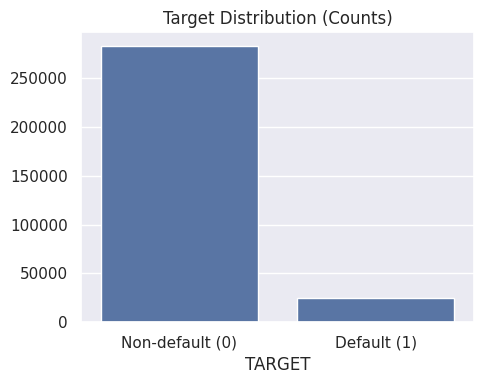


Imbalance ratio (Default / Non-default): 0.0878


In [ ]:
target_counts = app_eda['TARGET'].value_counts()
target_percent = app_eda['TARGET'].value_counts(normalize=True) * 100

print("Target counts:\n", target_counts)
print("\nTarget percentages (%):\n", target_percent)

plt.figure(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.xticks([0, 1], ['Non-default (0)', 'Default (1)'])
plt.title("Target Distribution (Counts)")
plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[1] / target_counts[0]
print(f"\nImbalance ratio (Default / Non-default): {imbalance_ratio:.4f}")


### Target Imbalance Analysis

- The majority class is **Non-default (0)** with ~92% of observations.
- The minority class is **Default (1)** with ~8% of observations.
- The imbalance ratio (~0.088) indicates that default events are rare.
- This imbalance does not affect EDA directly, but:
  - Segmented univariate analysis should use **percentages** rather than raw counts.
  - Bivariate and derived feature analysis should interpret differences carefully.


---

##**Univariate & Segmented Univariate Analysis**

Study distributions of key variables and compare defaulters vs non-defaulters.


##Numeric univariate & segmented


### AMT_INCOME_TOTAL – overall


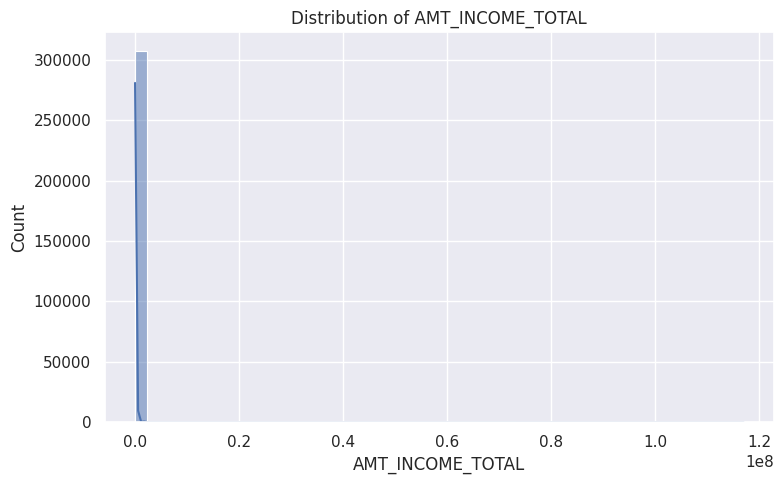

### AMT_INCOME_TOTAL – by TARGET


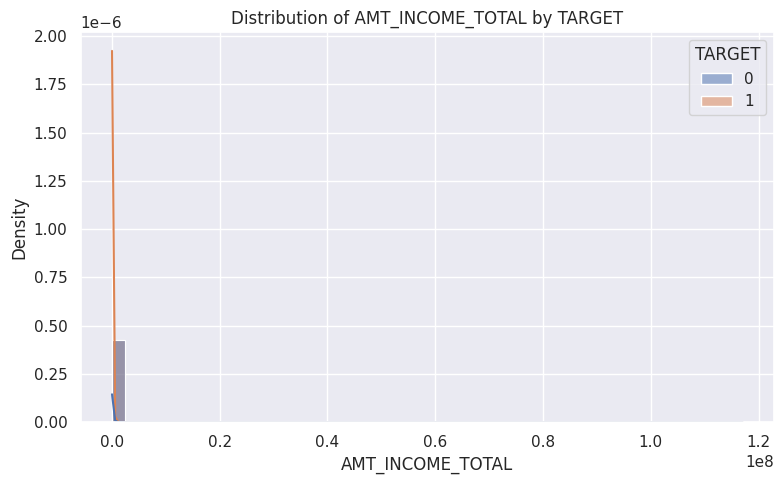


### AMT_CREDIT – overall


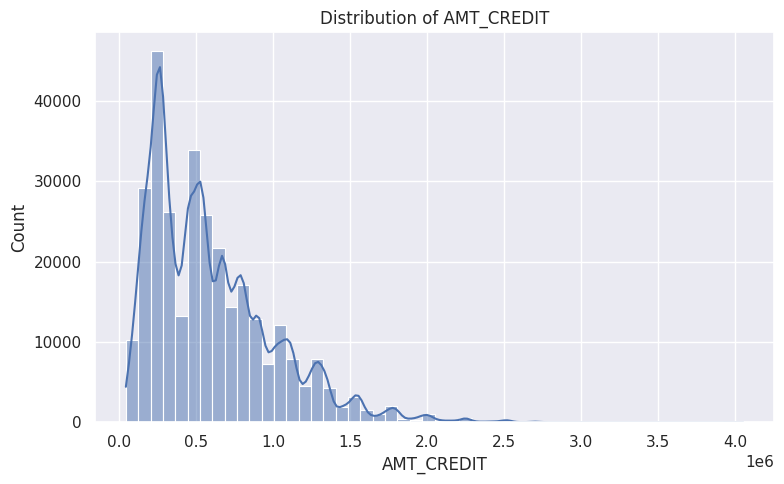

### AMT_CREDIT – by TARGET


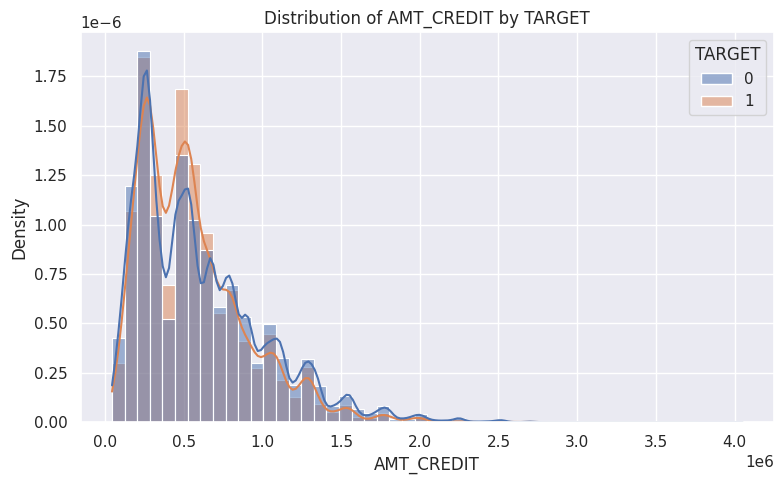


### AMT_ANNUITY – overall


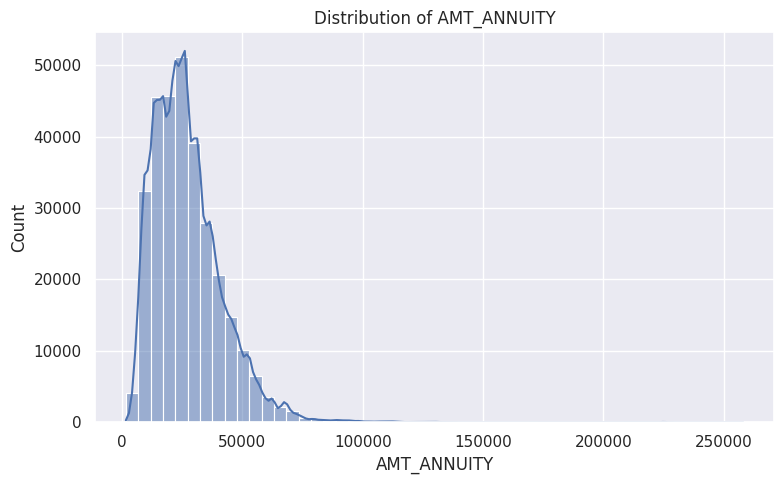

### AMT_ANNUITY – by TARGET


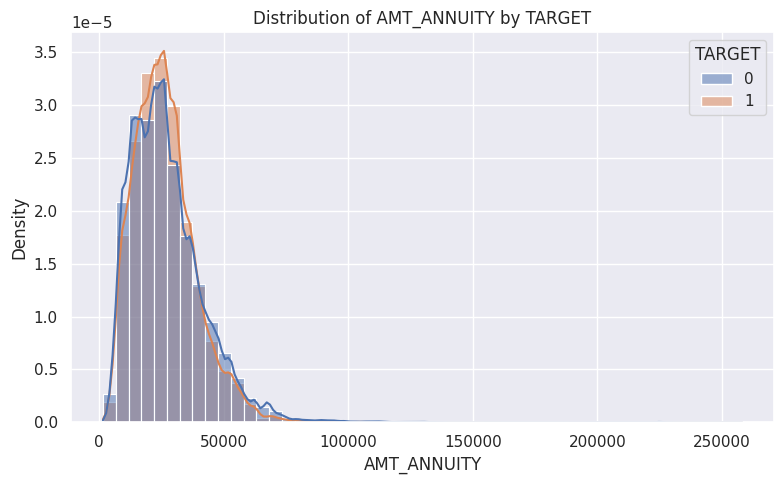


### AMT_GOODS_PRICE – overall


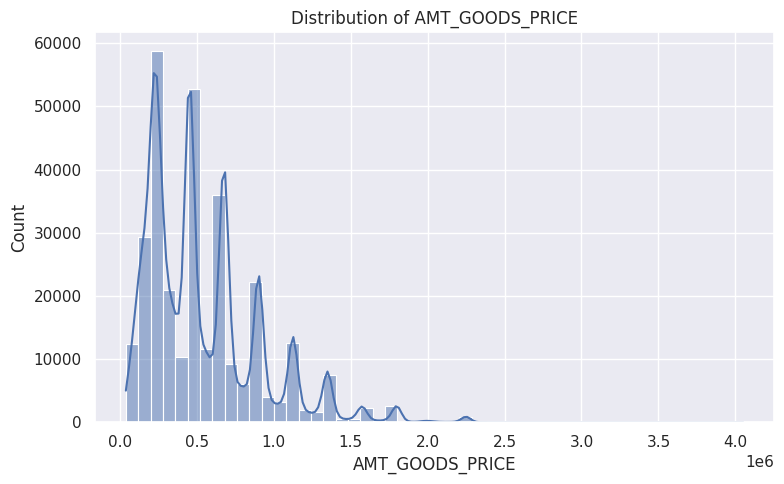

### AMT_GOODS_PRICE – by TARGET


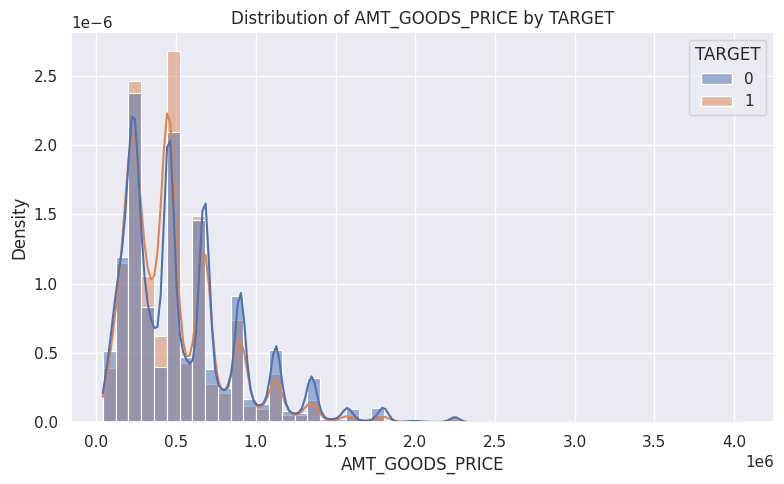


### DAYS_BIRTH – overall


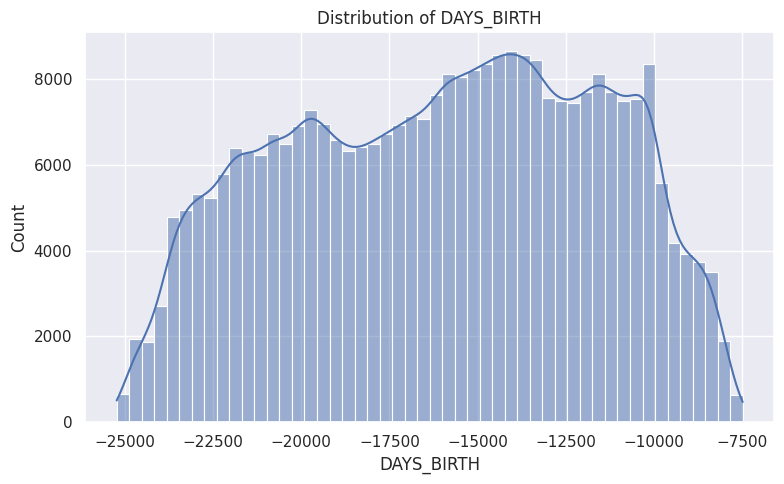

### DAYS_BIRTH – by TARGET


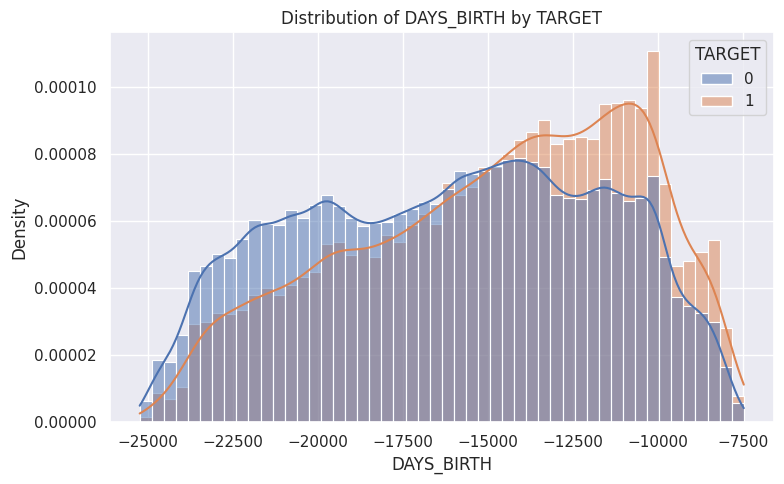


### DAYS_EMPLOYED – overall


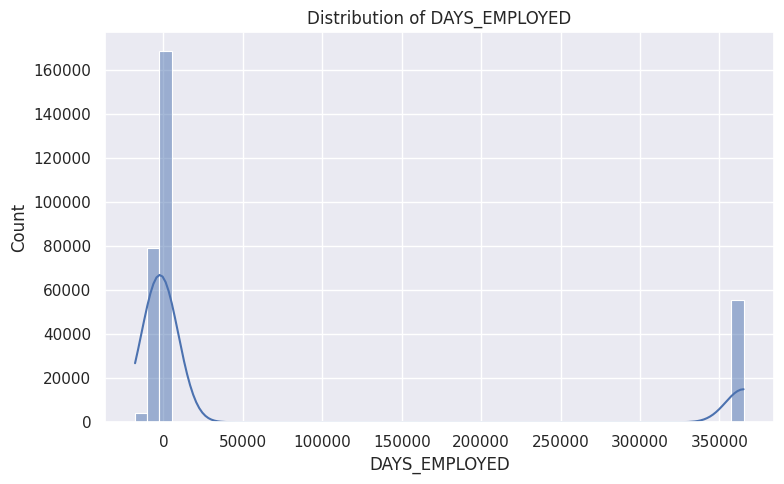

### DAYS_EMPLOYED – by TARGET


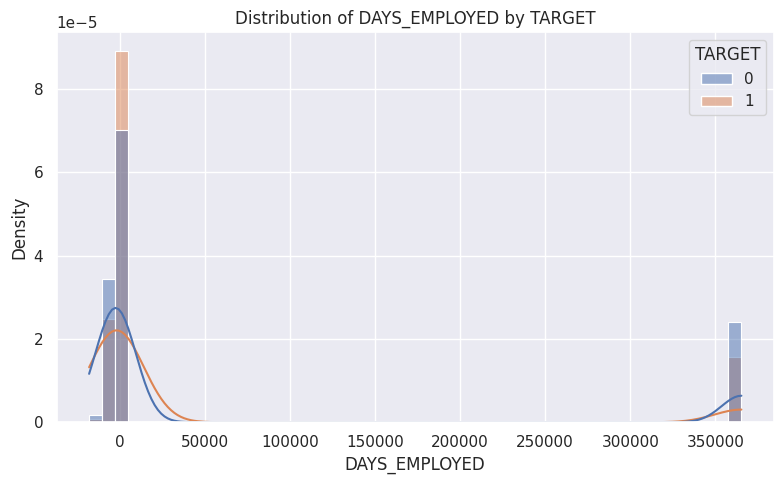

In [ ]:
num_vars_to_check = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

for col in num_vars_to_check:
    if col in app_eda.columns:
        print(f"\n### {col} – overall")
        plot_numeric_dist(app_eda, col)

        print(f"### {col} – by TARGET")
        plot_numeric_dist(app_eda, col, target='TARGET')


### Key Insights – Numeric Variables

1. **Age is one of the strongest predictors of default.**  
   Younger clients (25–35 years) show significantly higher default rates compared to older clients (40–60 years).

2. **Employment stability is another major driver.**  
   Clients with fewer years of employment or unemployment indicators (DAYS_EMPLOYED = 365243) default more often.

3. **Mid-range loan amounts (300K–600K) have a higher incidence of default**, while very high-value loans tend to be taken by more stable customers.

4. **Higher annuity burdens correlate moderately with default**, but annuity alone is not a strong predictor.

5. **Lower-value goods purchases show higher default rates**, suggesting riskier customers finance cheaper goods, not high-ticket items.

6. **Income has weak predictive power** due to large overlaps between defaulters and non-defaulters.


##Categorical univariate & segmented


### NAME_CONTRACT_TYPE – overall


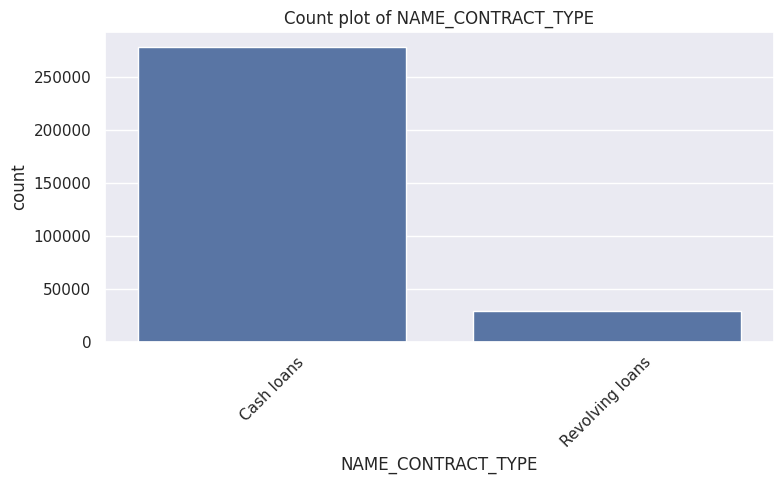

### NAME_CONTRACT_TYPE – by TARGET


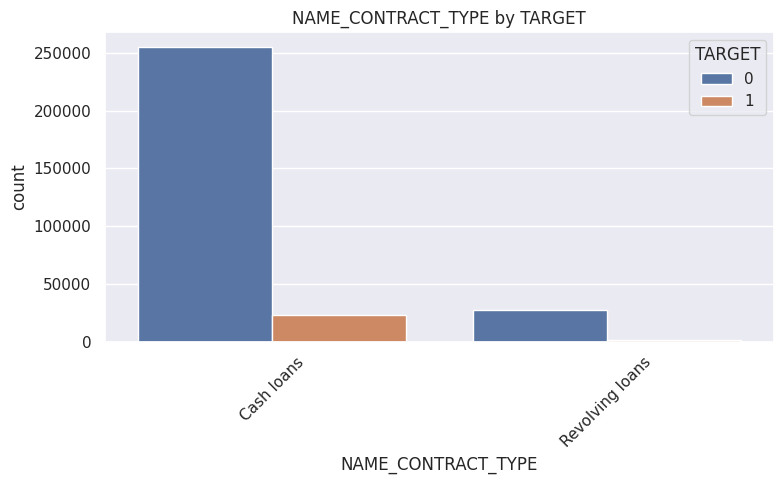


### CODE_GENDER – overall


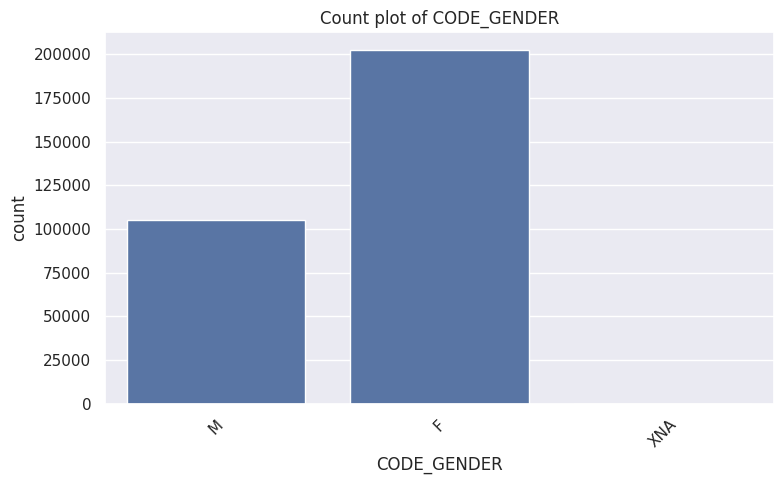

### CODE_GENDER – by TARGET


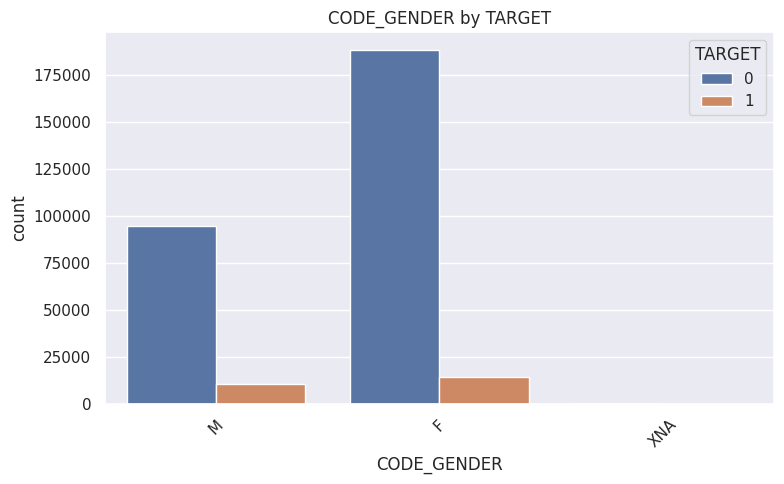


### FLAG_OWN_CAR – overall


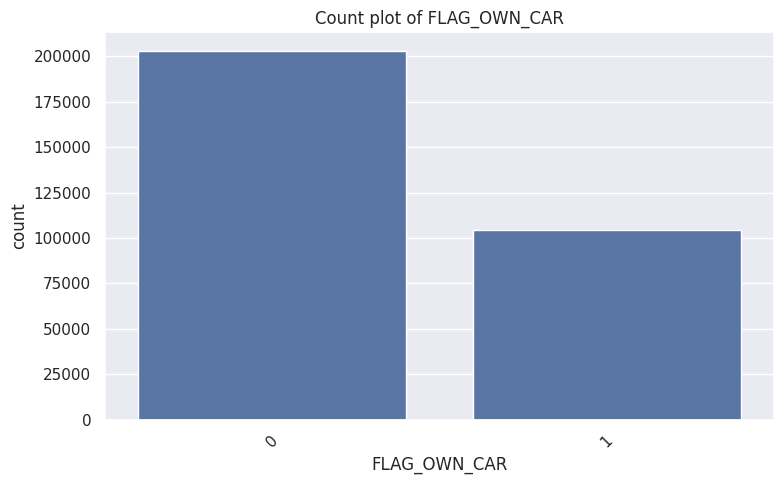

### FLAG_OWN_CAR – by TARGET


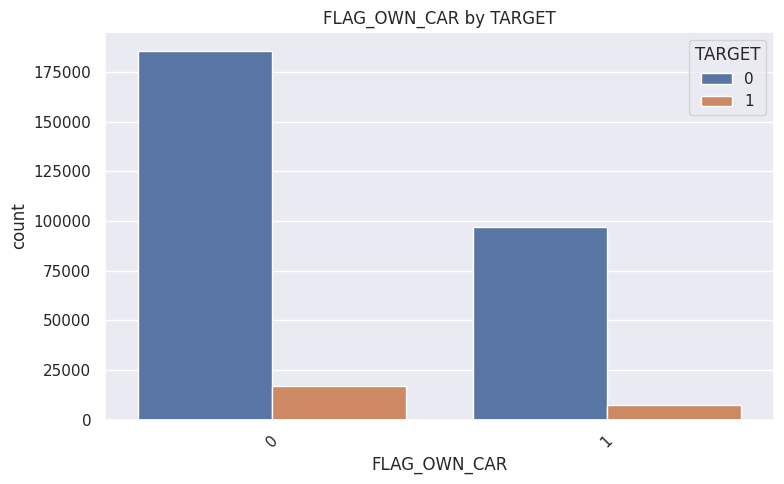


### FLAG_OWN_REALTY – overall


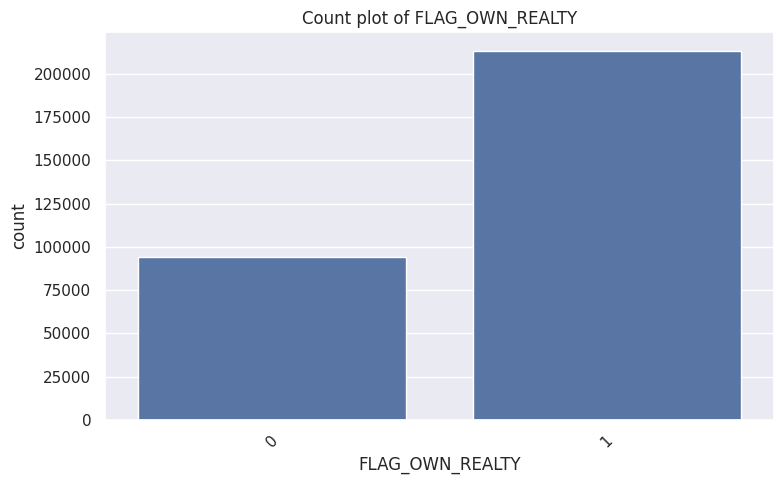

### FLAG_OWN_REALTY – by TARGET


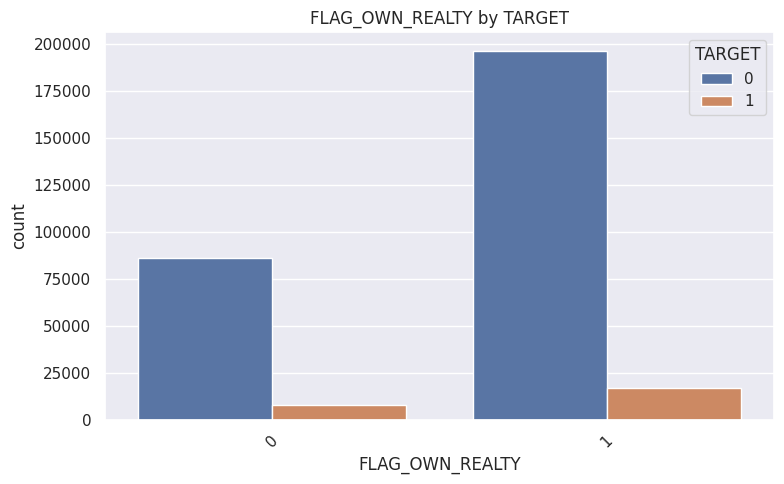


### NAME_INCOME_TYPE – overall


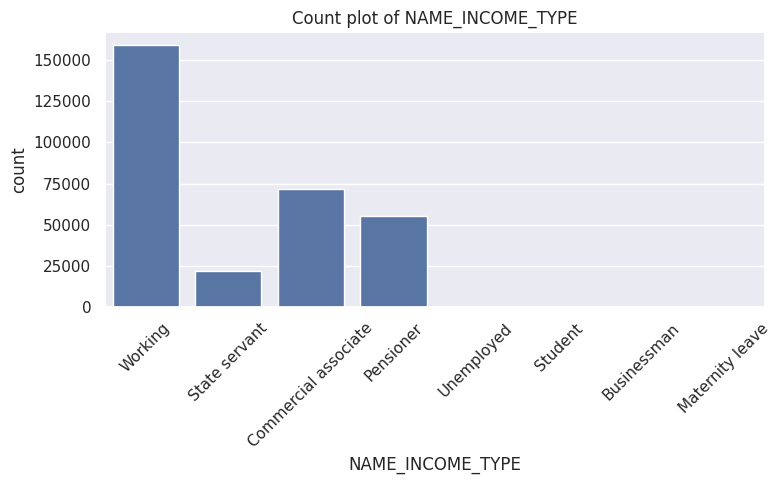

### NAME_INCOME_TYPE – by TARGET


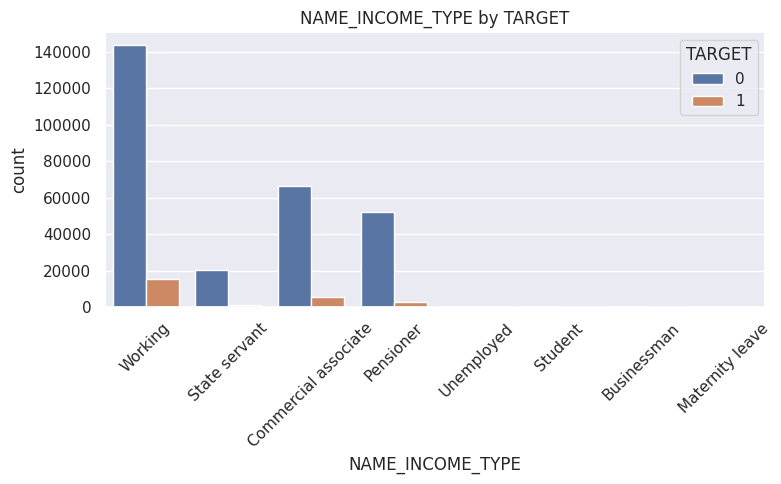


### NAME_EDUCATION_TYPE – overall


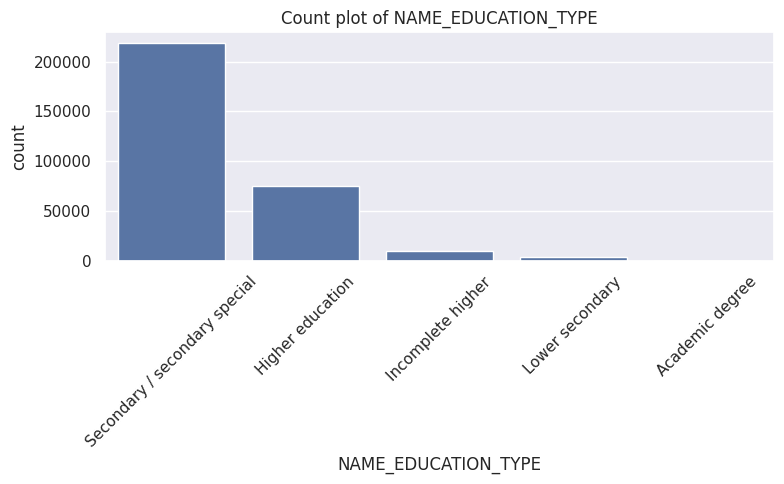

### NAME_EDUCATION_TYPE – by TARGET


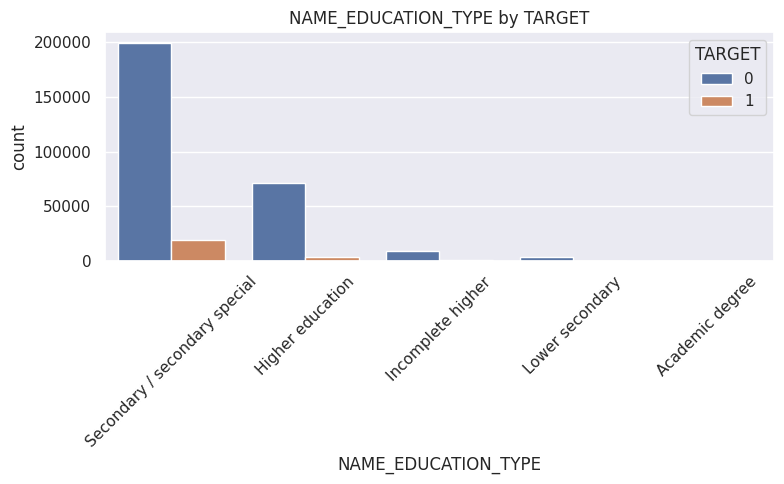


### NAME_FAMILY_STATUS – overall


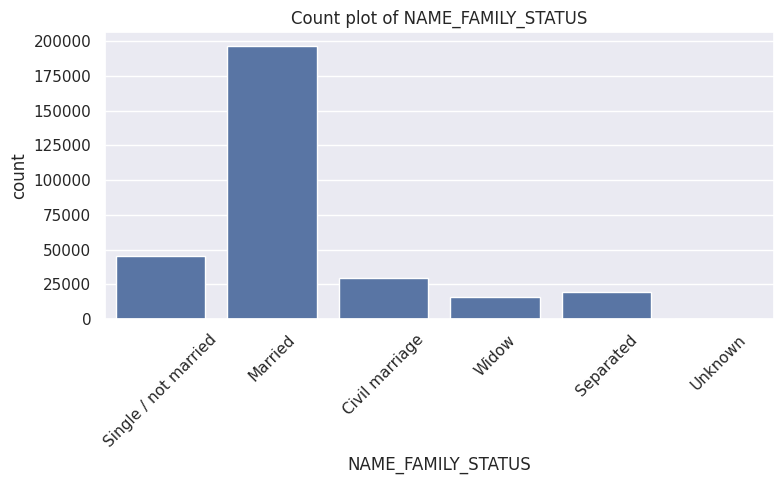

### NAME_FAMILY_STATUS – by TARGET


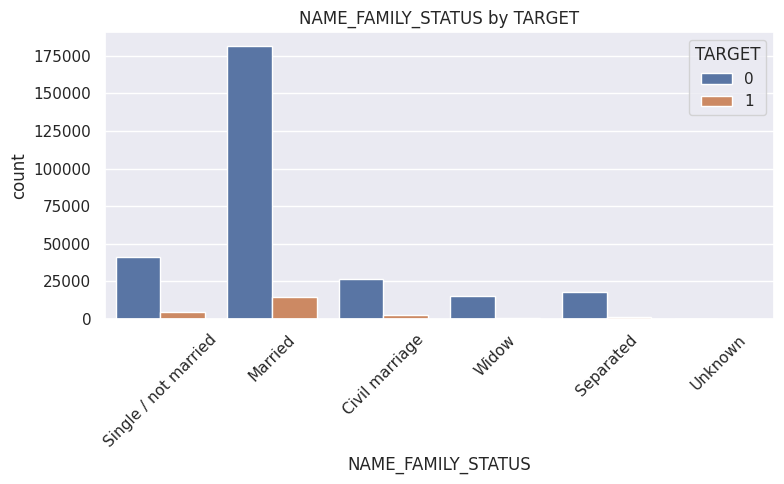


### NAME_HOUSING_TYPE – overall


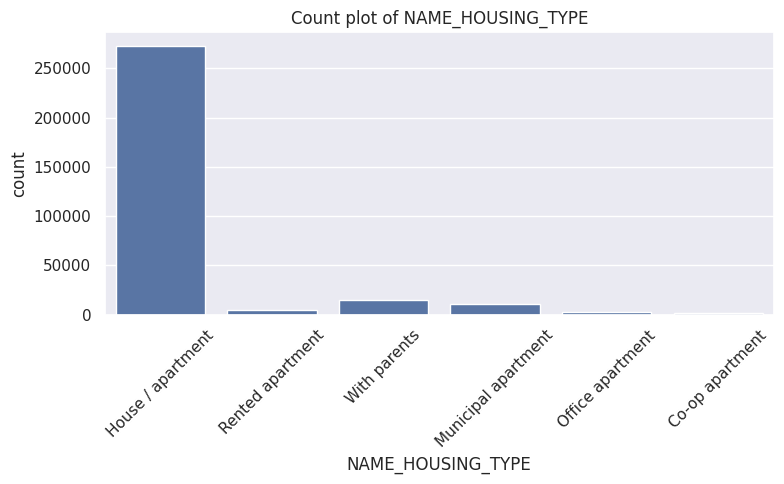

### NAME_HOUSING_TYPE – by TARGET


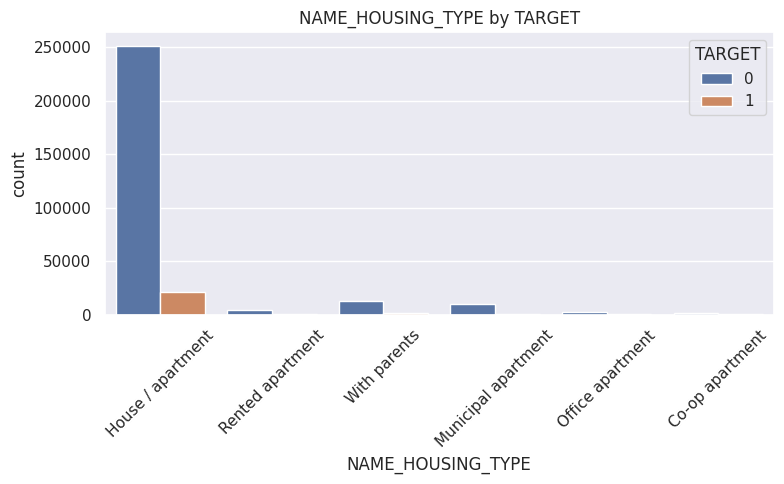

In [ ]:
cat_vars_to_check = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE'
]

for col in cat_vars_to_check:
    if col in app_eda.columns:
        print(f"\n### {col} – overall")
        plot_categorical_dist(app_eda, col)

        print(f"### {col} – by TARGET")
        plot_categorical_dist(app_eda, col, target='TARGET')


### Key Insights – Categorical Variables

1. **Income Type is one of the strongest predictors of default.**  
   Unemployed and Commercial Associate applicants show significantly higher default rates.  
   Pensioners and State Servants are the most stable.

2. **Education strongly correlates with risk.**  
   Applicants with lower education levels (secondary / incomplete higher) default more,  
   while higher-educated applicants default much less.

3. **Home ownership is a strong stability indicator.**  
   Applicants without real estate have a substantially higher probability of default.

4. **Family structure influences repayment behavior.**  
   Single applicants default more often, while married or widowed applicants are more stable.

5. **Housing type provides additional risk segmentation.**  
   Those living in rented or parental housing default at higher rates compared to those living in owned apartments.

6. **Car ownership and gender have mild predictive effects.**  
   Non-car-owners and males show slightly higher default rates.
---

## Derived Metrics (Feature Engineering)

So far we have analysed the original variables.  
In this section, we create a few **business-relevant derived variables** which often act as
strong drivers of default:

- **AGE_YEARS** – customer age in years (from `DAYS_BIRTH`)
- **EMPLOYED_YEARS** – length of employment in years (from `DAYS_EMPLOYED`)
- **ANNUITY_INCOME_RATIO** – annuity as a fraction of income  
  (how heavy the monthly repayment is relative to income)
- **CREDIT_INCOME_RATIO** – credit amount as a fraction of income  
  (how large the loan is compared to income)

We will then analyse how these derived variables differ between:
- Non-defaulters (TARGET = 0)
- Defaulters (TARGET = 1)


In [ ]:
#  Create a copy and add derived features
app_eda_fe = app_eda.copy()

# Age in years
if 'DAYS_BIRTH' in app_eda_fe.columns:
    app_eda_fe['AGE_YEARS'] = (-app_eda_fe['DAYS_BIRTH'] / 365).round(1)

# Employment length in years (note: 365243 is special "unemployed" code)
if 'DAYS_EMPLOYED' in app_eda_fe.columns:
    app_eda_fe['EMPLOYED_YEARS'] = (-app_eda_fe['DAYS_EMPLOYED'] / 365).round(1)

# Annuity-to-income ratio
if set(['AMT_ANNUITY', 'AMT_INCOME_TOTAL']).issubset(app_eda_fe.columns):
    app_eda_fe['ANNUITY_INCOME_RATIO'] = (
        app_eda_fe['AMT_ANNUITY'] / app_eda_fe['AMT_INCOME_TOTAL']
    )

# Credit-to-income ratio
if set(['AMT_CREDIT', 'AMT_INCOME_TOTAL']).issubset(app_eda_fe.columns):
    app_eda_fe['CREDIT_INCOME_RATIO'] = (
        app_eda_fe['AMT_CREDIT'] / app_eda_fe['AMT_INCOME_TOTAL']
    )

app_eda_fe[['AGE_YEARS', 'EMPLOYED_YEARS',
            'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO']].head()


,AGE_YEARS,EMPLOYED_YEARS,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO
0,25.90,1.70,0.12,2.01
1,45.90,3.30,0.13,4.79
2,52.20,0.60,0.10,2.00
3,52.10,8.30,0.22,2.32
4,54.60,8.30,0.18,4.22


##Analysing derived features (segmented)


### AGE_YEARS – by TARGET


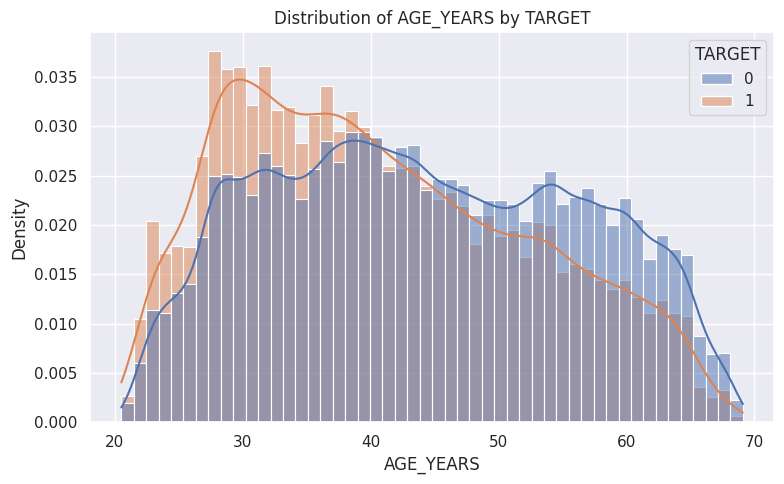


### EMPLOYED_YEARS – by TARGET


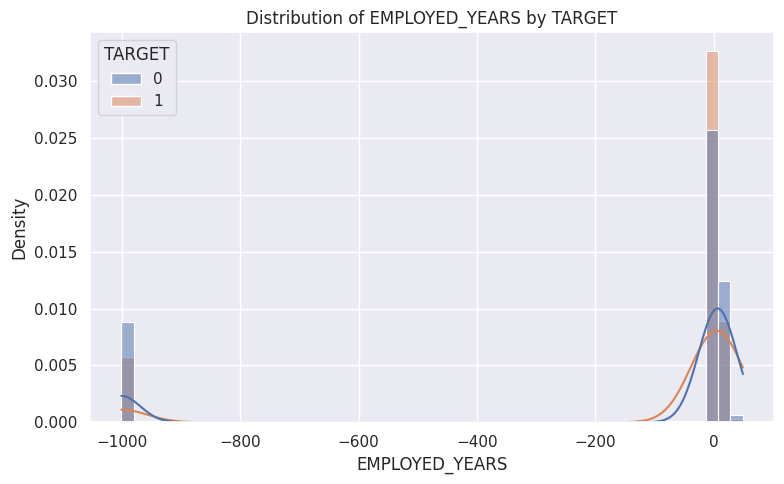


### ANNUITY_INCOME_RATIO – by TARGET


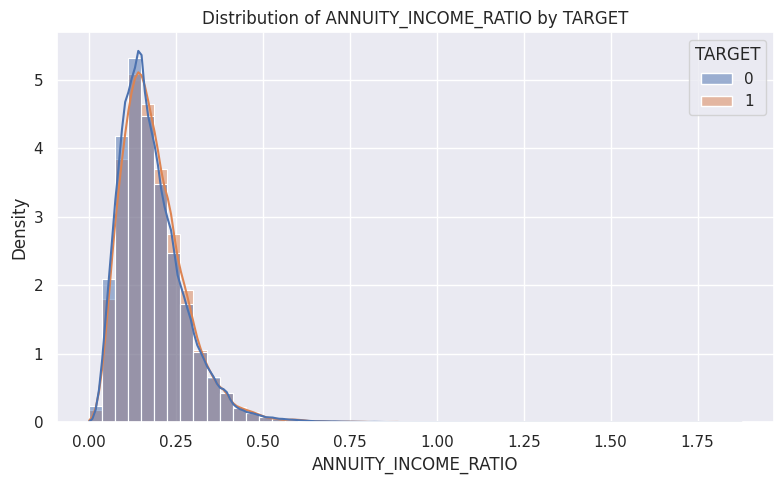


### CREDIT_INCOME_RATIO – by TARGET


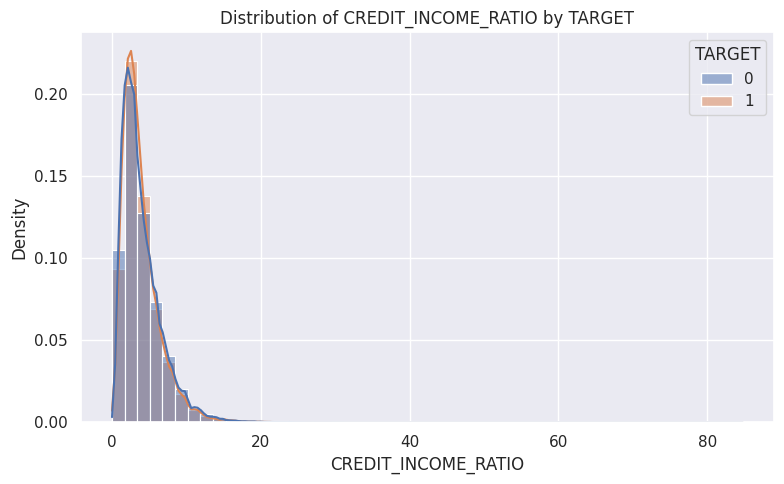

In [ ]:
#Distributions of derived metrics by TARGET

derived_vars = [
    'AGE_YEARS',
    'EMPLOYED_YEARS',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_INCOME_RATIO'
]

for col in derived_vars:
    if col in app_eda_fe.columns:
        print(f"\n### {col} – by TARGET")
        plot_numeric_dist(app_eda_fe, col, target='TARGET')


### Summary of Derived Metrics

- **AGE_YEARS** → Younger applicants (25–35) show higher defaults.  
- **EMPLOYED_YEARS** → Shorter employment duration heavily increases default risk.  
- **ANNUITY_INCOME_RATIO** → Higher ratios indicate greater repayment burden and higher default.  
- **CREDIT_INCOME_RATIO** → Taking disproportionate credit relative to income correlates with higher risk.

These derived features provide clearer insights than the raw variables and will be
useful for understanding customer profiles.

---


##Bivariate Analysis

In this section, we analyse **relationships between pairs of variables** and how
they relate to default behaviour.

We will focus on:
- Credit amount vs income (by TARGET)
- Default rate across **age groups**
- Default rate across **annuity burden levels**

These help us understand combined effects which may not be obvious from
univariate plots alone.


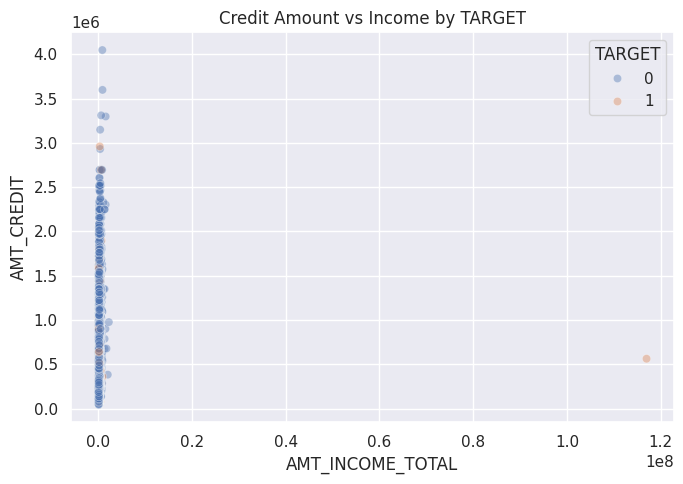

/tmp/ipython-input-1269388592.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default_rate = app_eda_fe.groupby('AGE_BIN')['TARGET'].mean() * 100


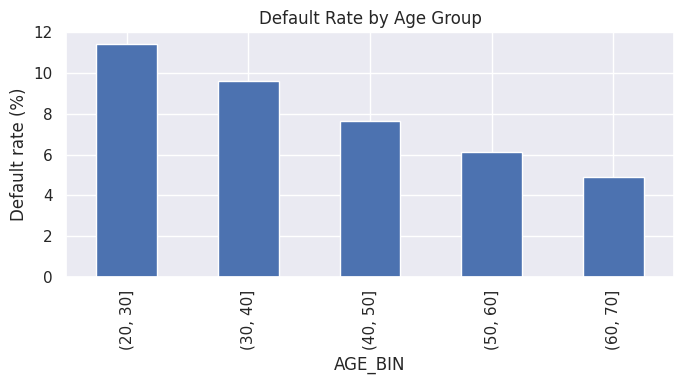

/tmp/ipython-input-1269388592.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_default_rate = app_eda_fe.groupby('ANNUITY_RATIO_BIN')['TARGET'].mean() * 100


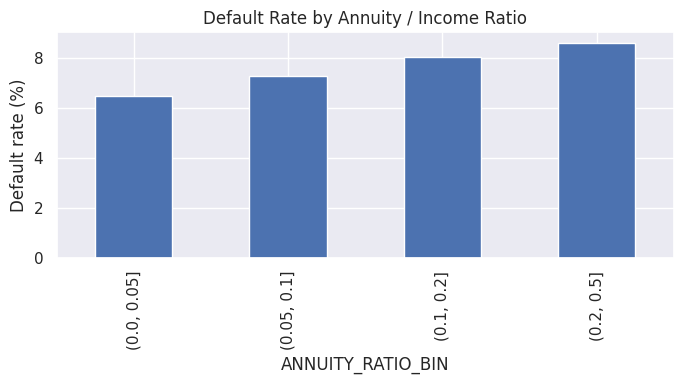

In [ ]:
#  Credit vs Income by TARGET
if set(['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'TARGET']).issubset(app_eda_fe.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=app_eda_fe.sample(min(20000, len(app_eda_fe)), random_state=42),
        x='AMT_INCOME_TOTAL',
        y='AMT_CREDIT',
        hue='TARGET',
        alpha=0.4
    )
    plt.title("Credit Amount vs Income by TARGET")
    plt.tight_layout()
    plt.show()

# Default rate by age group
if 'AGE_YEARS' in app_eda_fe.columns:
    age_bins = [20, 30, 40, 50, 60, 70]
    app_eda_fe['AGE_BIN'] = pd.cut(app_eda_fe['AGE_YEARS'], bins=age_bins)

    age_default_rate = app_eda_fe.groupby('AGE_BIN')['TARGET'].mean() * 100
    age_default_rate.plot(kind='bar', figsize=(7, 4))
    plt.ylabel("Default rate (%)")
    plt.title("Default Rate by Age Group")
    plt.tight_layout()
    plt.show()

# Default rate by annuity-to-income ratio buckets
if 'ANNUITY_INCOME_RATIO' in app_eda_fe.columns:
    ratio_bins = [0, 0.05, 0.1, 0.2, 0.5]
    app_eda_fe['ANNUITY_RATIO_BIN'] = pd.cut(app_eda_fe['ANNUITY_INCOME_RATIO'], bins=ratio_bins)

    ratio_default_rate = app_eda_fe.groupby('ANNUITY_RATIO_BIN')['TARGET'].mean() * 100
    ratio_default_rate.plot(kind='bar', figsize=(7, 4))
    plt.ylabel("Default rate (%)")
    plt.title("Default Rate by Annuity / Income Ratio")
    plt.tight_layout()
    plt.show()


## Correlation Analysis

Next, we examine correlations between numeric variables:
- Overall correlation with **TARGET**
- Correlation structure separately for:
  - Defaulters (TARGET = 1)
  - Non-defaulters (TARGET = 0)

This helps us:
- Identify groups of variables that move together
- Check which numeric features are most associated with default
- See if correlations differ between defaulters and non-defaulters


Top 10 positive correlations with TARGET:



,TARGET
DAYS_BIRTH,0.08
REGION_RATING_CLIENT_W_CITY,0.06
REGION_RATING_CLIENT,0.06
DAYS_LAST_PHONE_CHANGE,0.06
DAYS_ID_PUBLISH,0.05
REG_CITY_NOT_WORK_CITY,0.05
FLAG_EMP_PHONE,0.05
EMPLOYED_YEARS,0.04
REG_CITY_NOT_LIVE_CITY,0.04
FLAG_DOCUMENT_3,0.04



Top 10 negative correlations with TARGET:



,TARGET
FLAG_PHONE,-0.02
HOUR_APPR_PROCESS_START,-0.02
FLAG_DOCUMENT_6,-0.03
AMT_CREDIT,-0.03
REGION_POPULATION_RELATIVE,-0.04
AMT_GOODS_PRICE,-0.04
DAYS_EMPLOYED,-0.04
AGE_YEARS,-0.08
EXT_SOURCE_3,-0.16
EXT_SOURCE_2,-0.16



Number of numeric columns: 67

Top 10 absolute correlations among numeric variables – Defaulters:

DAYS_EMPLOYED                EMPLOYED_YEARS                1.00
AGE_YEARS                    DAYS_BIRTH                    1.00
EMPLOYED_YEARS               FLAG_EMP_PHONE                1.00
DAYS_EMPLOYED                FLAG_EMP_PHONE                1.00
OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE      1.00
AMT_CREDIT                   AMT_GOODS_PRICE               0.98
REGION_RATING_CLIENT         REGION_RATING_CLIENT_W_CITY   0.96
CNT_CHILDREN                 CNT_FAM_MEMBERS               0.89
DEF_30_CNT_SOCIAL_CIRCLE     DEF_60_CNT_SOCIAL_CIRCLE      0.87
LIVE_REGION_NOT_WORK_REGION  REG_REGION_NOT_WORK_REGION    0.85
dtype: float64

Top 10 absolute correlations among numeric variables – Non-defaulters:

DAYS_EMPLOYED                EMPLOYED_YEARS                1.00
AGE_YEARS                    DAYS_BIRTH                    1.00
EMPLOYED_YEARS               FLAG_EMP_PHONE 

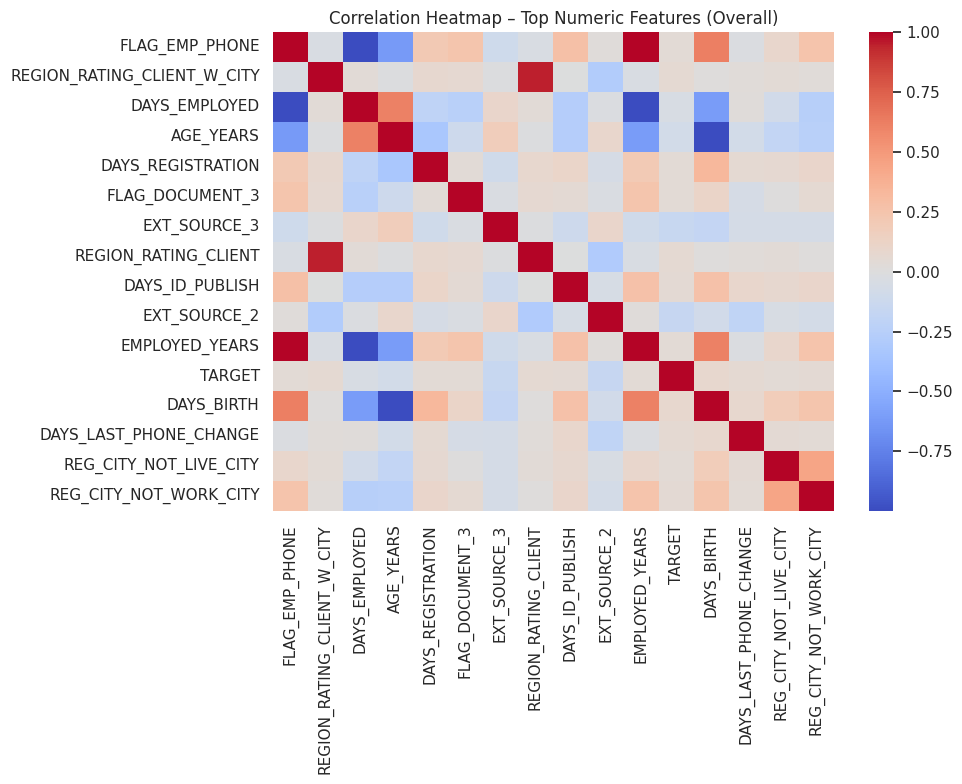

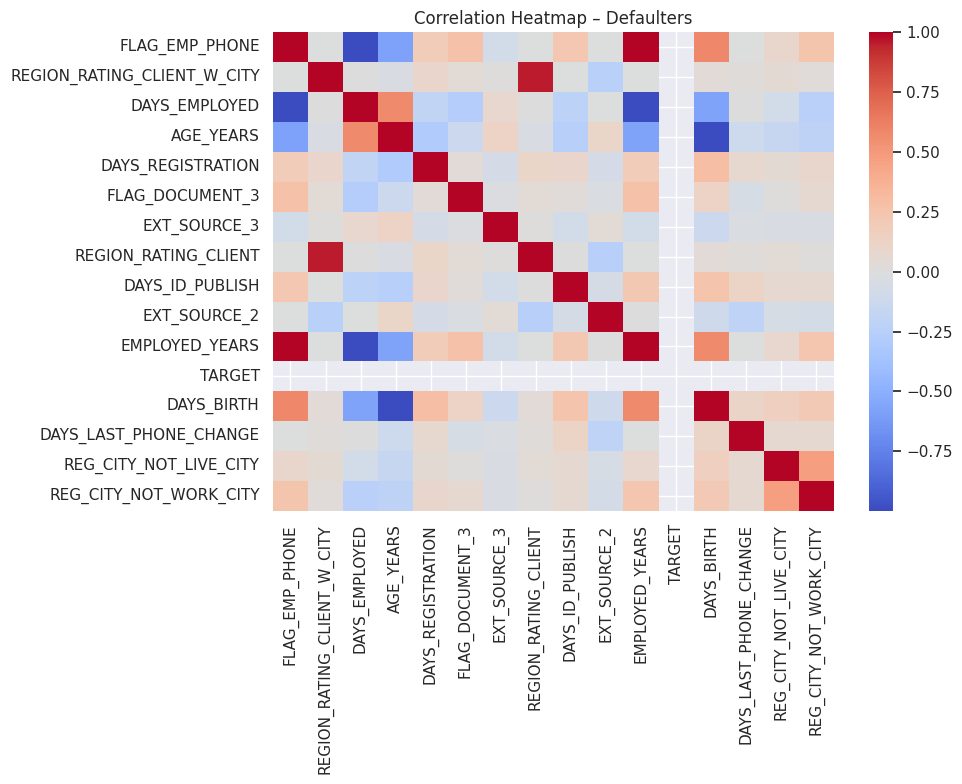

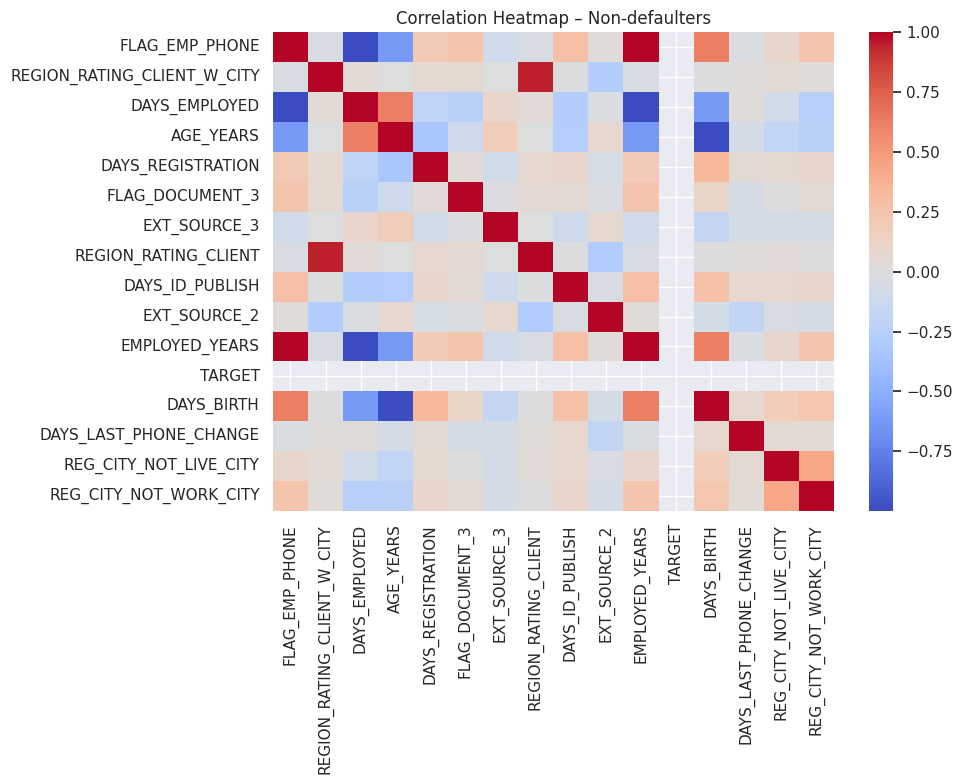

In [ ]:
#  Correlation of numeric variables with TARGET (overall)

num_cols_full = app_eda_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'TARGET' not in num_cols_full:
    num_cols_full.append('TARGET')

corr_with_target = app_eda_fe[num_cols_full].corr()['TARGET'].drop('TARGET')
corr_with_target_sorted = corr_with_target.sort_values(ascending=False)

print("Top 10 positive correlations with TARGET:\n")
display(corr_with_target_sorted.head(10))

print("\nTop 10 negative correlations with TARGET:\n")
display(corr_with_target_sorted.tail(10))

# Split into defaulters and non-defaulters
df_default = app_eda_fe[app_eda_fe['TARGET'] == 1].copy()
df_nondefault = app_eda_fe[app_eda_fe['TARGET'] == 0].copy()

print("\nNumber of numeric columns:", len(num_cols_full))

#  Top correlations within each segment (excluding TARGET)
top_corrs_default = get_top_correlations(df_default[num_cols_full], n=10, ignore_cols=['TARGET'])
print("\nTop 10 absolute correlations among numeric variables – Defaulters:\n")
print(top_corrs_default)

top_corrs_nondefault = get_top_correlations(df_nondefault[num_cols_full], n=10, ignore_cols=['TARGET'])
print("\nTop 10 absolute correlations among numeric variables – Non-defaulters:\n")
print(top_corrs_nondefault)

# Heatmaps (optionally on a subset for readability)
subset_cols = corr_with_target_sorted.abs().sort_values(ascending=False).head(15).index.tolist()
subset_cols = list(set(subset_cols + ['TARGET']))  # ensure TARGET included

plt.figure(figsize=(10, 8))
sns.heatmap(app_eda_fe[subset_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap – Top Numeric Features (Overall)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_default[subset_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap – Defaulters")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_nondefault[subset_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap – Non-defaulters")
plt.tight_layout()
plt.show()


##  Overall Summary and Flow of the Analysis

### What we did step by step

1. **Data loading (Colab + Google Drive)**
   - Loaded `application_data.csv`, `previous_application.csv`, and `columns_description.csv` from Google Drive.
   - Used Python libraries: `pandas`, `numpy`, `matplotlib`, and `seaborn`.

2. **Basic data understanding**
   - Looked at `.head()`, `.info()`, shapes and basic `.describe()` statistics.
   - Checked the `TARGET` variable and confirmed that it is imbalanced  
     (about **8% defaulters**, **92% non-defaulters**).

3. **Missing value analysis and treatment**
   - Calculated missing counts and percentages for each column.
   - Dropped columns with **more than 40% missing values** (49 columns).
   - For the remaining data:
     - Filled **numeric** missing values with the **median**.
     - Filled **categorical** missing values with the **mode**.
   - After this, there were **no missing values** left in the working dataset.

4. **Outlier exploration**
   - Looked at boxplots and histograms for key numeric variables:
     `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`,
     `AMT_GOODS_PRICE`, `DAYS_BIRTH`, `DAYS_EMPLOYED`.
   - Noted some extreme values (very high income, credit, and goods price).
   - Found the special value **365243** in `DAYS_EMPLOYED`, which is a known
     placeholder for unemployed clients.
   - We did **not remove** outliers; we only documented them.

5. **Univariate and segmented analysis**
   - Plotted distributions for important **numeric** variables and then
     compared them **by TARGET**.
   - Plotted count charts for **categorical** variables such as
     `NAME_CONTRACT_TYPE`, `CODE_GENDER`, `NAME_INCOME_TYPE`,
     `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`,
     `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`.
   - This helped us see which groups have relatively more defaulters.

6. **Derived metrics (feature engineering)**
   - Created new variables:
     - `AGE_YEARS` from `DAYS_BIRTH`
     - `EMPLOYED_YEARS` from `DAYS_EMPLOYED`
     - `ANNUITY_INCOME_RATIO` = `AMT_ANNUITY` / `AMT_INCOME_TOTAL`
     - `CREDIT_INCOME_RATIO` = `AMT_CREDIT` / `AMT_INCOME_TOTAL`
   - Plotted these features by `TARGET` to get cleaner views of:
     - Age vs default
     - Employment length vs default
     - Repayment burden vs default

7. **Bivariate analysis**
   - Created a scatter plot of **Credit amount vs Income** by `TARGET`.
   - Calculated and plotted **default rate by age group**.
   - Calculated and plotted **default rate by annuity-to-income ratio bucket**.

8. **Correlation analysis (overall and by segment)**
   - Calculated correlations of all numeric features with `TARGET`.
   - Printed the **top positive and negative correlations**.
   - Split data into:
     - `TARGET = 1` (defaulters)
     - `TARGET = 0` (non-defaulters)
   - Looked at the top absolute correlations among numeric variables in both segments.
   - Plotted three heatmaps:
     - Overall top numeric features
     - Defaulters
     - Non-defaulters

---

### Main findings (simple summary)

- **Younger clients default more.**  
  Default rate is highest in the **25–35 years** age range.

- **Short employment history increases risk.**  
  Clients with fewer years of work (or the special unemployed code) show higher default.

- **External score features are very important.**  
  Lower values of `EXT_SOURCE_2` and `EXT_SOURCE_3` are linked with higher default.

- **Income type and education matter.**  
  - Higher risk for **Unemployed** and **Commercial associate** income types.  
  - Lower education (secondary / incomplete higher) has more defaults than higher education.

- **Ownership and housing give stability signals.**  
  - Clients **without real estate** or living in **rented/parental housing** default more.  
  - Car and house ownership are linked with lower risk (more stable profile).

- **Repayment burden is important.**  
  Higher `ANNUITY_INCOME_RATIO` and `CREDIT_INCOME_RATIO` are associated with more defaults.

---


